# 05. 풍성순환 — Stommel · Munk gyre

바람이 해양 위에서 응력 $\tau$ 를 가하고, 마찰이 이를 소산시키면 정상상태의
**풍성순환(wind-driven gyre)** 이 만들어진다. 이 순환의 가장 인상적인 특징은
**서안경계강화(western intensification)** — 빠르고 좁은 서안경계류(예: 멕시코만류,
쿠로시오)가 서쪽 벽에 형성되는 것이다.

세 가지 균형:

- **Sverdrup 균형**(내부): $\beta V = \dfrac{1}{\rho_0}\,\nabla\times\tau$
  → 내부 흐름은 바람응력의 회전으로 정해진다.
- **Stommel**(바닥마찰 $-r\mathbf{u}$): 서안경계층 두께 $\delta_S = r/\beta$.
- **Munk**(측면점성 $A_h\nabla^2\mathbf{u}$): 서안경계층 두께 $\delta_M = (A_h/\beta)^{1/3}$.

학습 목표:

1. 바람응력 + 마찰 + $\beta$ 로 정상상태 gyre 를 spin-up 한다.
2. **서안경계강화**를 유선함수로 관찰한다.
3. **Stommel vs Munk** 경계층을 비교한다.
4. 내부의 **Sverdrup 균형**을 확인한다.

## 1. 라이브러리와 설정

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_project_root(markers=("pyproject.toml", ".git")):
    # 노트북에는 __file__ 이 없으므로 cwd 에서 위로 올라가며 루트를 찾는다.
    start = Path.cwd().resolve()
    for path in (start, *start.parents):
        if any((path / m).exists() for m in markers):
            return path
    return start.parent if start.name == "notebooks" else start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

from shallow_water.grids.cgrid import CGrid
from shallow_water.dynamics.swe2d import ShallowWater2D
from shallow_water.dynamics import diagnostics as diag
from shallow_water.forcing import wind
from shallow_water.utils.io import get_output_dirs

OUT = get_output_dirs(PROJECT_ROOT); FIG = OUT["figures"]

g, H, f0, beta = 9.81, 500.0, 1e-4, 2e-11
Lx = Ly = 2e6                          # 2000 km × 2000 km 분지
n = 100
grid = CGrid(nx=n, ny=n, Lx=Lx, Ly=Ly)   # 닫힌 분지
c = np.sqrt(g * H)
dt = 0.4 * grid.dx / (c * np.sqrt(2))
rho0, tau0 = 1025.0, 0.1
tau_x = wind.single_gyre_wind(grid.y_eta, Ly, tau0)   # τx(y) = -τ0 cos(πy/Ly)
print(f"basin {Lx/1e3:.0f} km, dx = {grid.dx/1e3:.0f} km, dt = {dt:.0f} s")

basin 2000 km, dx = 20 km, dt = 81 s


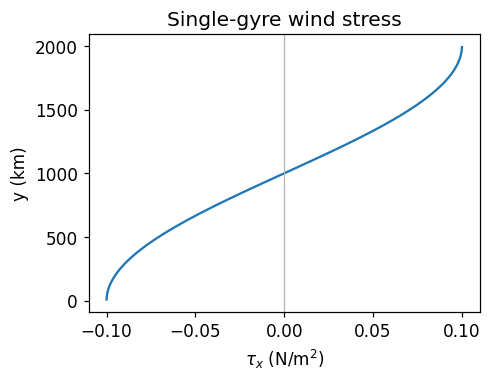

In [2]:
fig, ax = plt.subplots(figsize=(4.6, 3.6))
ax.plot(tau_x, grid.y_eta/1e3, "C0")
ax.axvline(0, color="0.7", lw=0.8)
ax.set_xlabel(r"$\tau_x$ (N/m$^2$)"); ax.set_ylabel("y (km)")
ax.set_title("Single-gyre wind stress")
fig.tight_layout(); fig.savefig(FIG / "05_wind_stress.png", bbox_inches="tight"); plt.show()

## 2. Stommel gyre (바닥마찰)

선형 바닥마찰 $-r\mathbf{u}$ 을 더해 정상상태까지 적분한다. spin-up 시간은
대략 $1/r$ 규모다. 정상상태의 **수송 유선함수** $\psi$ ($u=-\partial\psi/\partial y$)
를 그리면 서쪽에 몰린 좁은 경계류가 보인다.

In [3]:
r = 3e-6
delta_S = r / beta
model_s = ShallowWater2D(grid=grid, g=g, H=H, f0=f0, beta=beta, r=r,
                         tau_x=tau_x, rho0=rho0)
e0, u0, v0 = grid.zeros()
Tspin = 20 * 86400
ns = int(round(Tspin / dt))
res_s = model_s.run(e0, u0, v0, dt, ns, save_every=ns // 40, track_energy=True)
psi_s = diag.transport_streamfunction(grid, res_s["u"])
print(f"Stommel: δ_S = r/β = {delta_S/1e3:.0f} km, {ns} steps, {Tspin/86400:.0f} days")
print(f"정상상태 도달(에너지 변화): {(res_s['energy'][-1]/res_s['energy'][-2]-1)*100:.2e} %")

Stommel: δ_S = r/β = 150 km, 21394 steps, 20 days
정상상태 도달(에너지 변화): 1.24e-04 %


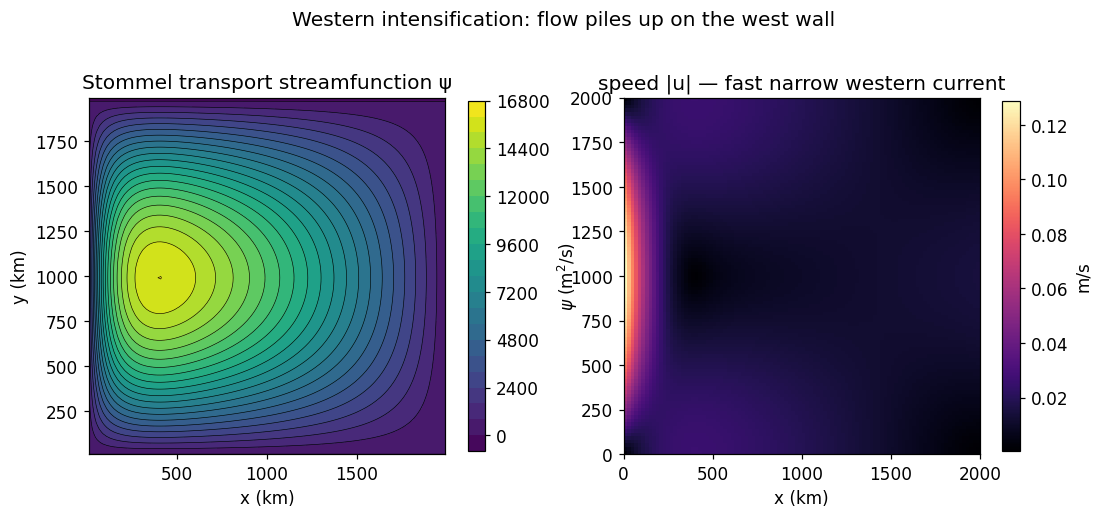

In [4]:
xkm, ykm = grid.x_eta/1e3, grid.y_eta/1e3
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
# 유선함수
cf = axes[0].contourf(xkm, ykm, psi_s, 21, cmap="viridis")
axes[0].contour(xkm, ykm, psi_s, 21, colors="k", linewidths=0.4)
axes[0].set_title("Stommel transport streamfunction ψ"); axes[0].set_aspect("equal")
axes[0].set_xlabel("x (km)"); axes[0].set_ylabel("y (km)")
fig.colorbar(cf, ax=axes[0], label=r"$\psi$ (m$^2$/s)", shrink=0.9)
# 표층 유속 크기
spd = np.hypot(grid.u_at_center(res_s["u"]), grid.v_at_center(res_s["v"]))
im = axes[1].pcolormesh(xkm, ykm, spd, cmap="magma", shading="auto")
axes[1].set_title("speed |u| — fast narrow western current"); axes[1].set_aspect("equal")
axes[1].set_xlabel("x (km)")
fig.colorbar(im, ax=axes[1], label="m/s", shrink=0.9)
fig.suptitle("Western intensification: flow piles up on the west wall", y=1.02)
fig.savefig(FIG / "05_stommel_gyre.png", bbox_inches="tight"); plt.show()

### Spin-up 시계열

정상상태에 도달할 때까지 총 에너지가 어떻게 증가하다 평탄해지는지 본다.

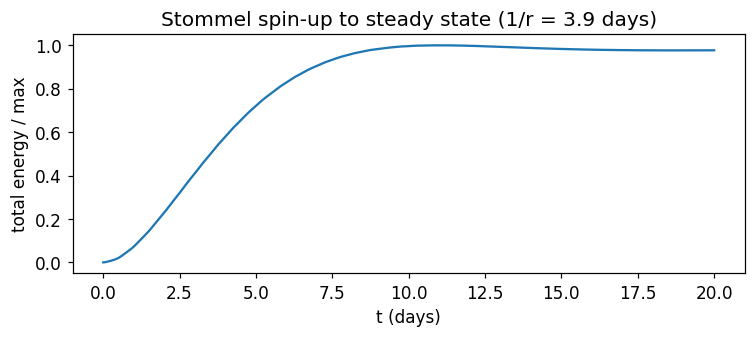

In [5]:
E = res_s["energy"]; tdays = res_s["times"] / 86400
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(tdays, E / E.max())
ax.set_xlabel("t (days)"); ax.set_ylabel("total energy / max")
ax.set_title(f"Stommel spin-up to steady state (1/r = {1/r/86400:.1f} days)")
fig.tight_layout(); fig.savefig(FIG / "05_spinup.png", bbox_inches="tight"); plt.show()

## 3. Stommel vs Munk

**Munk** 모형은 바닥마찰 대신 측면점성 $A_h\nabla^2\mathbf{u}$ 으로 소산한다.
경계에서 no-slip($\mathbf{u}=0$)이라 서안경계류가 벽에서 0이 되고 약간 앞바다에서
최댓값을 가지며, 바깥쪽에 약한 **반류(return flow) overshoot** 가 생긴다.
경계층 두께는 $\delta_M=(A_h/\beta)^{1/3}$.

Munk: δ_M = (A_h/β)^(1/3) = 100 km


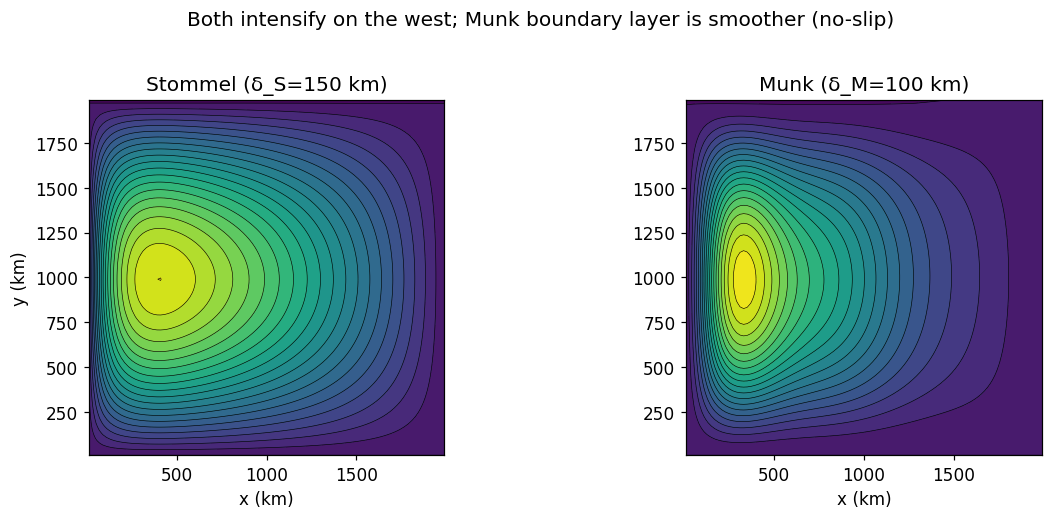

In [6]:
A_h = 2e4
delta_M = (A_h / beta) ** (1/3)
model_m = ShallowWater2D(grid=grid, g=g, H=H, f0=f0, beta=beta, A_h=A_h,
                         tau_x=tau_x, rho0=rho0)
res_m = model_m.run(*grid.zeros(), dt, int(round(30*86400/dt)),
                    save_every=None, track_energy=True)
psi_m = diag.transport_streamfunction(grid, res_m["u"])
print(f"Munk: δ_M = (A_h/β)^(1/3) = {delta_M/1e3:.0f} km")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
for ax, psi, title in zip(axes, [psi_s, psi_m],
                          [f"Stommel (δ_S={delta_S/1e3:.0f} km)",
                           f"Munk (δ_M={delta_M/1e3:.0f} km)"]):
    cf = ax.contourf(xkm, ykm, psi, 21, cmap="viridis")
    ax.contour(xkm, ykm, psi, 21, colors="k", linewidths=0.4)
    ax.set_title(title); ax.set_aspect("equal"); ax.set_xlabel("x (km)")
axes[0].set_ylabel("y (km)")
fig.suptitle("Both intensify on the west; Munk boundary layer is smoother (no-slip)", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "05_stommel_vs_munk.png", bbox_inches="tight"); plt.show()

### 서안경계층 단면

분지 중앙 위도에서 남북유속 $v(x)$ 의 단면을 보면, 두 모형 모두 서쪽 좁은 영역에
강한 흐름이 몰려 있다. 경계층 폭이 각각 $\delta_S,\ \delta_M$ 규모임을 확인한다.

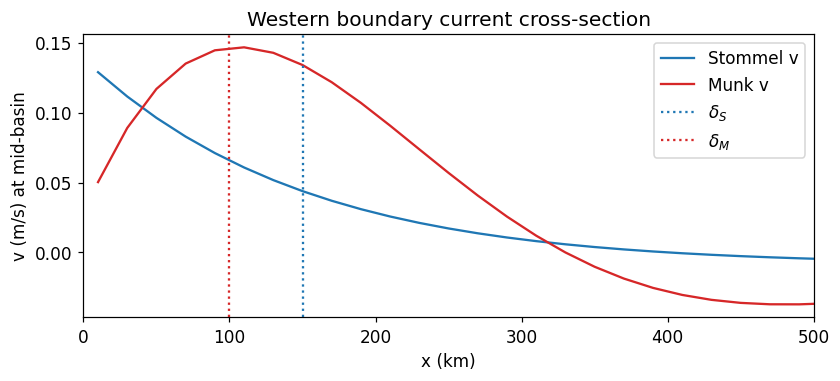

In [7]:
jmid = n // 2
vc_s = grid.v_at_center(res_s["v"])[jmid]
vc_m = grid.v_at_center(res_m["v"])[jmid]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(xkm, vc_s, "C0", label="Stommel v")
ax.plot(xkm, vc_m, "C3", label="Munk v")
ax.axvline(delta_S/1e3, color="C0", ls=":", label=r"$\delta_S$")
ax.axvline(delta_M/1e3, color="C3", ls=":", label=r"$\delta_M$")
ax.set_xlim(0, 500); ax.set_xlabel("x (km)"); ax.set_ylabel("v (m/s) at mid-basin")
ax.set_title("Western boundary current cross-section"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "05_boundary_layer.png", bbox_inches="tight"); plt.show()

## 4. 내부의 Sverdrup 균형

서안경계류 바깥의 **내부**에서는 Sverdrup 균형이 성립한다.

$$
\beta\,v \approx \frac{1}{\rho_0 H}\,\big(\nabla\times\tau\big)_z
= \frac{1}{\rho_0 H}\Big(-\frac{\partial \tau_x}{\partial y}\Big).
$$

모델 내부의 $v(y)$ (서안경계 제외 x-평균)를 Sverdrup 예측과 비교한다.

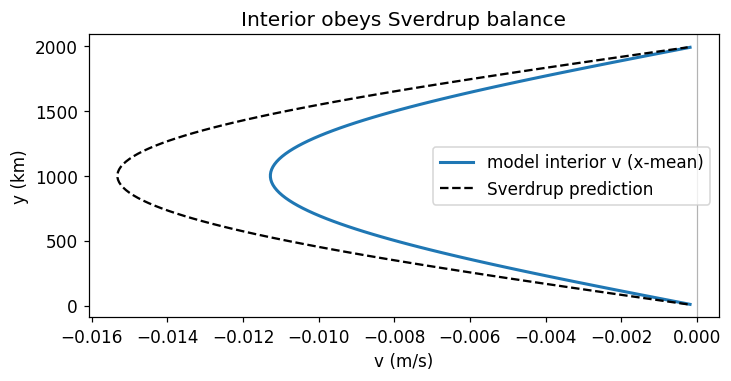

내부 v 상관: corr = 1.000


In [8]:
curl_tau = wind.wind_stress_curl(grid.y_eta, Ly, tau0, "single")   # = -dτx/dy
v_sv = curl_tau / (rho0 * H * beta)
# 내부(서안경계 제외) x-평균: x = 40%~90%
inside = (grid.x_eta > 0.4 * Lx) & (grid.x_eta < 0.9 * Lx)
v_model = grid.v_at_center(res_s["v"])[:, inside].mean(axis=1)
fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.plot(v_model, ykm, "C0", lw=2, label="model interior v (x-mean)")
ax.plot(v_sv, ykm, "k--", label="Sverdrup prediction")
ax.axvline(0, color="0.7", lw=0.8)
ax.set_xlabel("v (m/s)"); ax.set_ylabel("y (km)")
ax.set_title("Interior obeys Sverdrup balance"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "05_sverdrup.png", bbox_inches="tight"); plt.show()
print(f"내부 v 상관: corr = {np.corrcoef(v_model, v_sv)[0,1]:.3f}")

## 5. 정리

- 바람응력 + 마찰 + $\beta$ 로 정상상태 풍성순환을 spin-up 했다.
- **서안경계강화**: 흐름이 서쪽 벽에 좁고 빠르게 몰린다(멕시코만류·쿠로시오의 원리).
- **Stommel**(바닥마찰, $\delta_S=r/\beta$)과 **Munk**(측면점성, $\delta_M=(A_h/\beta)^{1/3}$)
  경계층을 비교했다.
- 분지 **내부**는 바람응력 회전이 정하는 **Sverdrup 균형**을 따른다.

다음(Stage 6)에서는 **이중 gyre(double-gyre)** 순환을 만들고, 그 속도장을
입자추적·트레이서 수송에 연결하는 **capstone** 실험을 한다.